In [13]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

np.random.seed(42)

In [14]:
import os
os.chdir(r"C:\Users\HP\Downloads")

Loaded image shape: (75, 75)
Data type: uint8
Value range: 0 to 255


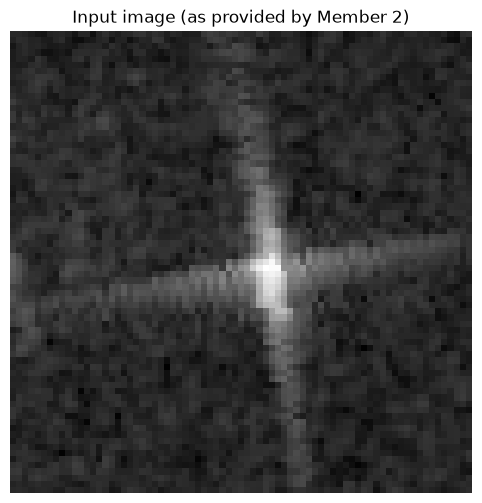

In [15]:
IMAGE_PATH = "sample_shiporice.png"   # <-- change to your actual file path

raw_image = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)

if raw_image is None:
    raise FileNotFoundError(f"Could not load '{IMAGE_PATH}'. Check the path.")

print("Loaded image shape:", raw_image.shape)
print("Data type:", raw_image.dtype)
print("Value range:", raw_image.min(), "to", raw_image.max())

plt.figure(figsize=(6, 6))
plt.imshow(raw_image, cmap="gray")
plt.title("Input image (as provided by Member 2)")
plt.axis("off")
plt.show()

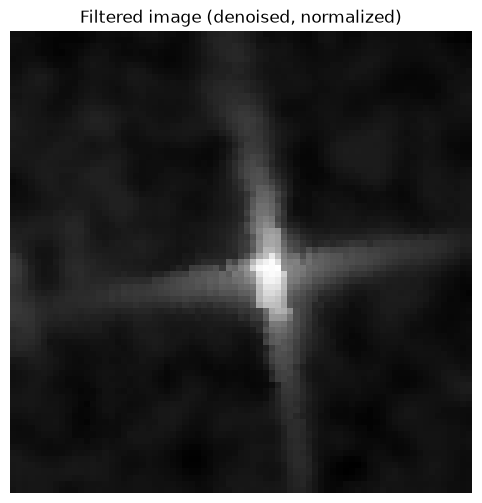

In [16]:
def denoise_and_normalize(band):
    denoised = cv2.bilateralFilter(band, d=7, sigmaColor=40, sigmaSpace=40)
    normalized = denoised.astype(np.float32) / 255.0
    return normalized

filtered_image = denoise_and_normalize(raw_image)

plt.figure(figsize=(6, 6))
plt.imshow(filtered_image, cmap="gray")
plt.title("Filtered image (denoised, normalized)")
plt.axis("off")
plt.show()

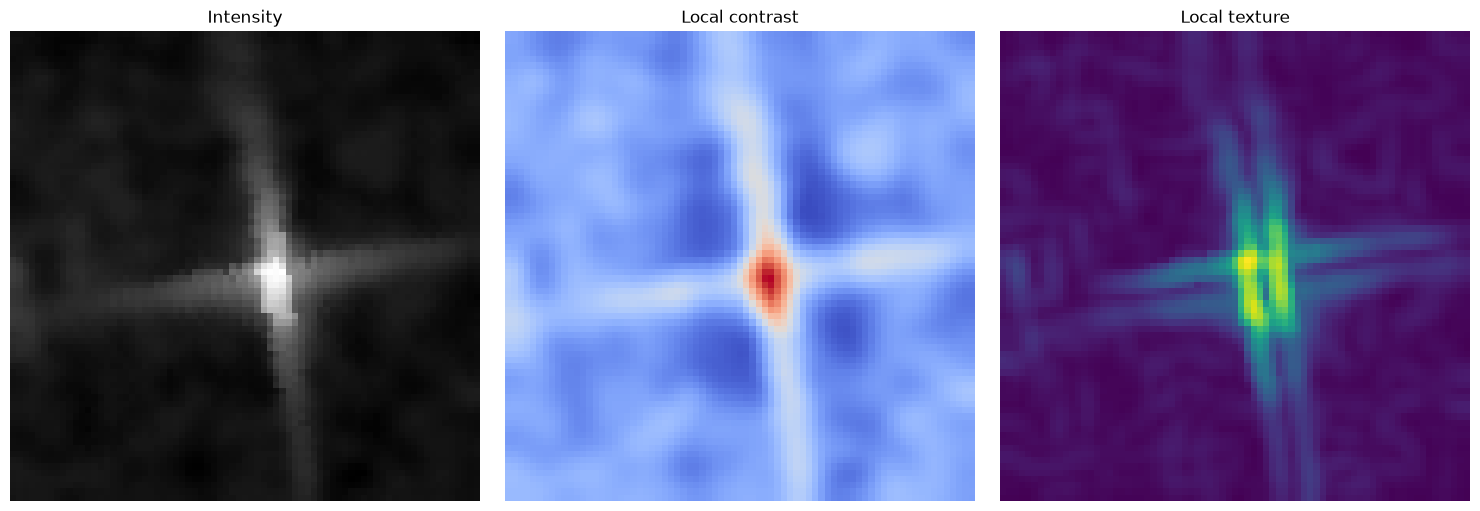

In [17]:
def compute_local_contrast(image, small_kernel=5, large_kernel=25):
    local_mean = cv2.boxFilter(image, ddepth=-1, ksize=(small_kernel, small_kernel))
    background_mean = cv2.boxFilter(image, ddepth=-1, ksize=(large_kernel, large_kernel))
    contrast = (local_mean - background_mean) / (background_mean + 1e-6)
    return contrast

def compute_local_texture(image, kernel=5):
    mean = cv2.boxFilter(image, ddepth=-1, ksize=(kernel, kernel))
    mean_of_squares = cv2.boxFilter(image ** 2, ddepth=-1, ksize=(kernel, kernel))
    variance = mean_of_squares - mean ** 2
    texture = np.sqrt(np.clip(variance, 0, None))
    return texture

contrast_map = compute_local_contrast(filtered_image)
texture_map = compute_local_texture(filtered_image)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(filtered_image, cmap="gray"); axes[0].set_title("Intensity")
axes[1].imshow(contrast_map, cmap="coolwarm"); axes[1].set_title("Local contrast")
axes[2].imshow(texture_map, cmap="viridis"); axes[2].set_title("Local texture")
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()

In [18]:
h, w = filtered_image.shape   # <-- if you ever see "h is not defined" later, it means THIS cell didn't run

features = np.stack([
    filtered_image.ravel(),
    contrast_map.ravel(),
    texture_map.ravel(),
], axis=1)

feature_means = features.mean(axis=0)
feature_stds = features.std(axis=0) + 1e-8
features_scaled = (features - feature_means) / feature_stds

print("Feature matrix shape:", features_scaled.shape)

Feature matrix shape: (5625, 3)


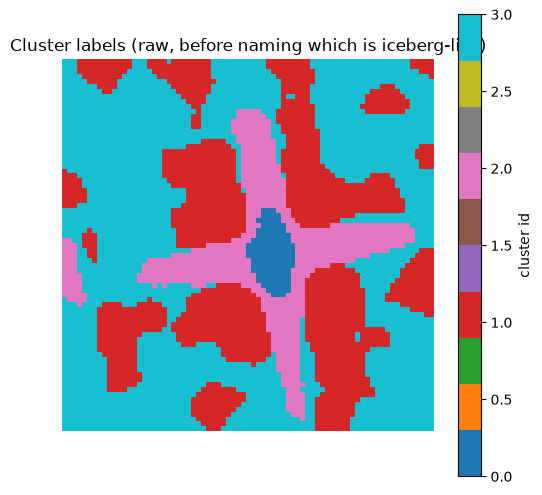

In [19]:
def kmeans_numpy_single_run(data, k, n_iter, rng):
    init_idx = rng.choice(data.shape[0], size=k, replace=False)
    centers = data[init_idx].copy()
    for iteration in range(n_iter):
        distances = cdist(data, centers)
        labels = np.argmin(distances, axis=1)
        new_centers = np.array([
            data[labels == c].mean(axis=0) if np.any(labels == c) else centers[c]
            for c in range(k)
        ])
        if np.allclose(new_centers, centers):
            centers = new_centers
            break
        centers = new_centers
    final_distances = cdist(data, centers)
    labels = np.argmin(final_distances, axis=1)
    inertia = np.sum(np.min(final_distances, axis=1) ** 2)
    return centers, labels, final_distances, inertia

def kmeans_numpy(data, k, n_iter=50, n_init=10, seed=42):
    rng = np.random.default_rng(seed)
    best_result, best_inertia = None, np.inf
    for attempt in range(n_init):
        centers, labels, distances, inertia = kmeans_numpy_single_run(data, k, n_iter, rng)
        if inertia < best_inertia:
            best_inertia = inertia
            best_result = (centers, labels, distances)
    return best_result

N_CLUSTERS = 4
centers, labels, distances = kmeans_numpy(features_scaled, k=N_CLUSTERS, n_init=10)
labels_img = labels.reshape(h, w)

def soft_probabilities(distances, bandwidth=None):
    if bandwidth is None:
        bandwidth = np.median(distances)
    weights = np.exp(-(distances ** 2) / (2 * bandwidth ** 2))
    probs = weights / weights.sum(axis=1, keepdims=True)
    return probs

probs = soft_probabilities(distances)
probs_img = probs.reshape(h, w, -1)

plt.figure(figsize=(6, 6))
plt.imshow(labels_img, cmap="tab10")
plt.title("Cluster labels (raw, before naming which is iceberg-like)")
plt.axis("off"); plt.colorbar(label="cluster id"); plt.show()

In [20]:
def cluster_solidity(mask):
    mask_u8 = (mask.astype(np.uint8)) * 255
    contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    solidities = []
    for c in contours:
        area = cv2.contourArea(c)
        if area < 15:
            continue
        hull = cv2.convexHull(c)
        hull_area = cv2.contourArea(hull)
        if hull_area > 0:
            solidities.append(area / hull_area)
    return np.mean(solidities) if solidities else 0.0

cluster_stats = []
for k in range(N_CLUSTERS):
    mask_k = labels_img == k
    pixel_count = int(mask_k.sum())
    mean_intensity = float(filtered_image[mask_k].mean()) if pixel_count > 0 else 0.0
    mean_contrast = float(contrast_map[mask_k].mean()) if pixel_count > 0 else 0.0
    solidity_k = cluster_solidity(mask_k)
    cluster_stats.append({"cluster": k, "mean_intensity": mean_intensity,
                           "mean_contrast": mean_contrast, "solidity": solidity_k,
                           "pixel_count": pixel_count})

for s in sorted(cluster_stats, key=lambda x: -x["mean_intensity"]):
    print(f"cluster {s['cluster']}: mean_intensity={s['mean_intensity']:.3f}  "
          f"mean_contrast={s['mean_contrast']:.3f}  solidity={s['solidity']:.3f}  "
          f"pixels={s['pixel_count']}")

def normalize_scores(values):
    values = np.array(values, dtype=np.float32)
    if values.max() - values.min() < 1e-8:
        return np.zeros_like(values)
    return (values - values.min()) / (values.max() - values.min())

intensities = normalize_scores([s["mean_intensity"] for s in cluster_stats])
contrasts = normalize_scores([s["mean_contrast"] for s in cluster_stats])
solidities = normalize_scores([s["solidity"] for s in cluster_stats])
composite_scores = 0.5 * intensities + 0.3 * contrasts + 0.2 * solidities

for i, s in enumerate(cluster_stats):
    s["composite_score"] = float(composite_scores[i])

ranked = sorted(cluster_stats, key=lambda x: -x["composite_score"])
print("\nRanked by composite iceberg-likelihood score:")
for s in ranked:
    print(f"cluster {s['cluster']}: composite_score={s['composite_score']:.3f}")

iceberg_cluster = ranked[0]["cluster"]
print(f"\nSelected cluster {iceberg_cluster} as the primary iceberg-like region.")

cluster 0: mean_intensity=0.597  mean_contrast=0.820  solidity=0.915  pixels=122
cluster 2: mean_intensity=0.283  mean_contrast=0.219  solidity=0.610  pixels=716
cluster 3: mean_intensity=0.167  mean_contrast=0.017  solidity=0.580  pixels=2954
cluster 1: mean_intensity=0.146  mean_contrast=-0.197  solidity=0.850  pixels=1833

Ranked by composite iceberg-likelihood score:
cluster 0: composite_score=1.000
cluster 2: composite_score=0.292
cluster 1: composite_score=0.162
cluster 3: composite_score=0.087

Selected cluster 0 as the primary iceberg-like region.


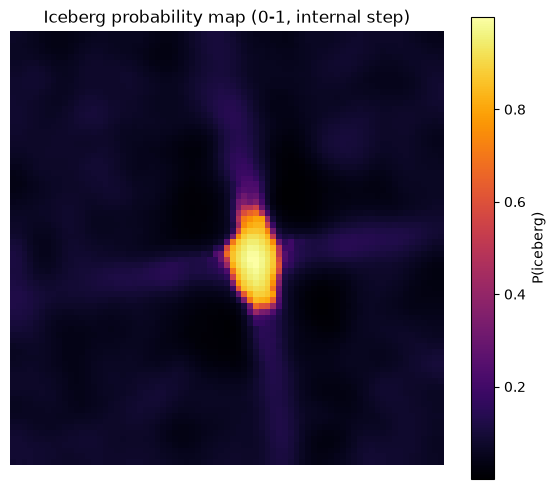

Risk map shape (should match input image shape): (75, 75)
Risk value range: 9.234971999483772e-05 to 8.997441038850956


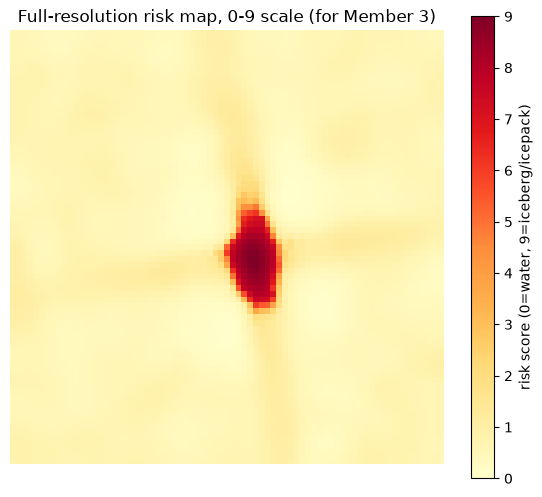

In [21]:
iceberg_prob_map = probs_img[:, :, iceberg_cluster]

contrast_normalized = (contrast_map - contrast_map.min()) / (contrast_map.max() - contrast_map.min() + 1e-8)
final_probability_map = 0.7 * iceberg_prob_map + 0.3 * contrast_normalized

plt.figure(figsize=(7, 6))
plt.imshow(final_probability_map, cmap="inferno")
plt.title("Iceberg probability map (0-1, internal step)")
plt.colorbar(label="P(iceberg)")
plt.axis("off")
plt.show()

def probability_to_risk_score(probability_map):
    risk_score = probability_map * 9.0
    risk_score = np.clip(risk_score, 0.0, 9.0)
    return risk_score

risk_map = probability_to_risk_score(final_probability_map)

print("Risk map shape (should match input image shape):", risk_map.shape)
print("Risk value range:", risk_map.min(), "to", risk_map.max())

plt.figure(figsize=(7, 6))
plt.imshow(risk_map, cmap="YlOrRd", vmin=0, vmax=9)
plt.title("Full-resolution risk map, 0-9 scale (for Member 3)")
plt.colorbar(label="risk score (0=water, 9=iceberg/icepack)")
plt.axis("off")
plt.show()

In [22]:
output_filename = f"risk_map_{risk_map.shape[0]}x{risk_map.shape[1]}.csv"
np.savetxt(output_filename, risk_map, delimiter=",", fmt="%.4f")

print(f"Saved {output_filename} — shape: {risk_map.shape}")
print("Value range:", risk_map.min(), "to", risk_map.max())
print("\n0-2: open water | 3-6: medium-high sea ice (risky) | 7-9: solid icepack/iceberg")

Saved risk_map_75x75.csv — shape: (75, 75)
Value range: 9.234971999483772e-05 to 8.997441038850956

0-2: open water | 3-6: medium-high sea ice (risky) | 7-9: solid icepack/iceberg
